In [1]:
#!pip install nibabel


[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip



   ---------------------------------------- 0.0/3.3 MB ? eta -:--:--
   --- ------------------------------------ 0.3/3.3 MB 10.2 MB/s eta 0:00:01
   -------- ------------------------------- 0.7/3.3 MB 8.4 MB/s eta 0:00:01
   ---------- ----------------------------- 0.9/3.3 MB 8.2 MB/s eta 0:00:01
   ------------ --------------------------- 1.0/3.3 MB 6.0 MB/s eta 0:00:01
   -------------- ------------------------- 1.2/3.3 MB 5.4 MB/s eta 0:00:01
   --------------- ------------------------ 1.3/3.3 MB 5.1 MB/s eta 0:00:01
   ------------------- -------------------- 1.6/3.3 MB 5.1 MB/s eta 0:00:01
   ----------------------- ---------------- 1.9/3.3 MB 5.2 MB/s eta 0:00:01
   -------------------------- ------------- 2.2/3.3 MB 5.4 MB/s eta 0:00:01
   ------------------------------ --------- 2.5/3.3 MB 5.6 MB/s eta 0:00:01
   ---------------------------------- ----- 2.9/3.3 MB 5.7 MB/s eta 0:00:01
   -------------------------------------- - 3.2/3.3 MB 5.7 MB/s eta 0:00:01
   --------------

In [4]:
import numpy as np
import nibabel as nib
import glob
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from tifffile import imsave

In [3]:
#!pip install tifffile

   ---------------------------------------- 0.0/228.2 kB ? eta -:--:--
   ---------------------------------------- 228.2/228.2 kB 4.6 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()

In [6]:
import tensorflow as tf

In [7]:
print(tf.__version__)

2.17.0


In [13]:
train_dataset_directory="E:\BraTS 2020\BraTS2020_TrainingData"

In [17]:
test_image_flair=nib.load(train_dataset_directory+"\MICCAI_BraTS2020_TrainingData\BraTS20_Training_355\BraTS20_Training_355_flair.nii").get_fdata()

In [20]:
print(test_image_flair.max())

1854.603271484375


In [21]:
test_image_flair=scaler.fit_transform(test_image_flair.reshape(-1, test_image_flair.shape[-1])).reshape(test_image_flair.shape)

In [22]:
test_image_flair.max()

1.0

In [23]:
test_image_t1=nib.load(train_dataset_directory+"\MICCAI_BraTS2020_TrainingData\BraTS20_Training_355\BraTS20_Training_355_t1.nii").get_fdata()
test_image_t1=scaler.fit_transform(test_image_t1.reshape(-1, test_image_t1.shape[-1])).reshape(test_image_t1.shape)

In [24]:
test_image_t2=nib.load(train_dataset_directory+"\MICCAI_BraTS2020_TrainingData\BraTS20_Training_355\BraTS20_Training_355_t2.nii").get_fdata()
test_image_t2=scaler.fit_transform(test_image_t2.reshape(-1, test_image_t2.shape[-1])).reshape(test_image_t2.shape)

In [35]:
test_image_t1ce=nib.load(train_dataset_directory+"\MICCAI_BraTS2020_TrainingData\BraTS20_Training_355\BraTS20_Training_355_t1ce.nii").get_fdata()
test_image_t1ce=scaler.fit_transform(test_image_t1ce.reshape(-1, test_image_t1ce.shape[-1])).reshape(test_image_t1ce.shape)

In [26]:
test_mask=nib.load(train_dataset_directory+"\MICCAI_BraTS2020_TrainingData\BraTS20_Training_355\BraTS20_Training_355_seg.nii").get_fdata()


In [27]:
test_mask=test_mask.astype(np.uint8)

In [28]:
np.unique(test_mask)

array([0, 1, 2, 4], dtype=uint8)

In [29]:
test_mask[test_mask==4]=3

In [30]:
print(np.unique(test_mask))

[0 1 2 3]


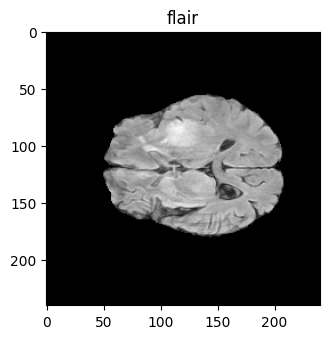

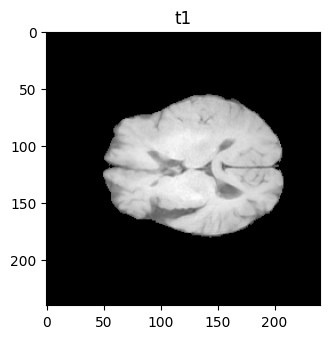

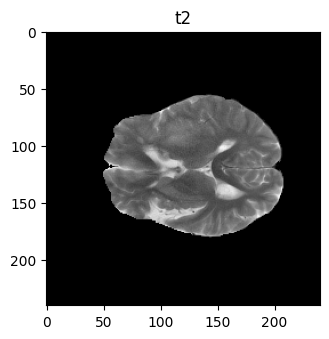

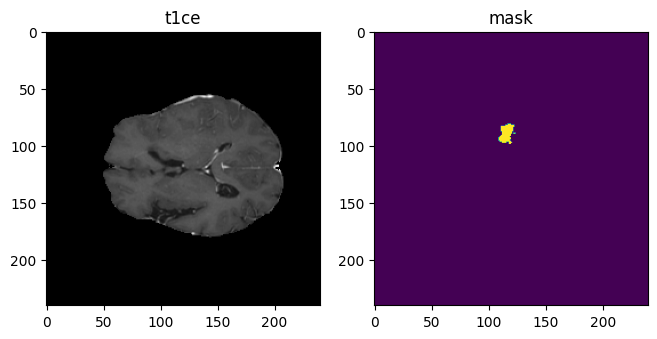

In [49]:
import random 
n_slice=random.randint(0, test_mask.shape[2])
plt.figure(figsize=(12,8))
plt.subplot(231)
plt.title("flair")
plt.imshow(test_image_flair[:,:,n_slice],cmap='gray')


plt.figure(figsize=(12,8))
plt.subplot(232)
plt.title("t1")
plt.imshow(test_image_t1[:,:,n_slice],cmap='gray')



plt.figure(figsize=(12,8))
plt.subplot(233)
plt.title("t2")
plt.imshow(test_image_t2[:,:,n_slice],cmap='gray')



plt.figure(figsize=(12,8))
plt.subplot(234)
plt.title("t1ce")
plt.imshow(test_image_t1ce[:,:,n_slice],cmap='gray')



plt.subplot(235)
plt.title("mask")
plt.imshow(test_mask[:,:,n_slice])
plt.show()

In [51]:
combined_x=np.stack([test_image_t1ce,test_image_t2,test_image_flair],axis=3)

In [52]:
combined_x=combined_x[56:184, 56:184, 13:141]

In [53]:
test_mask=test_mask[56:184, 56:184, 13:141]

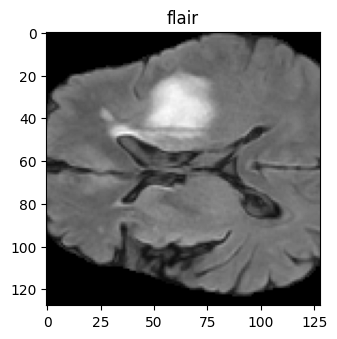

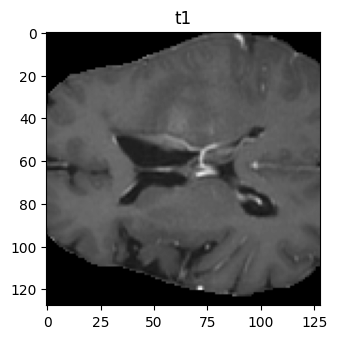

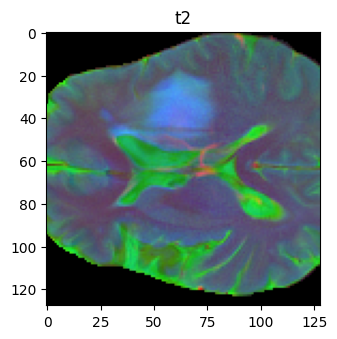

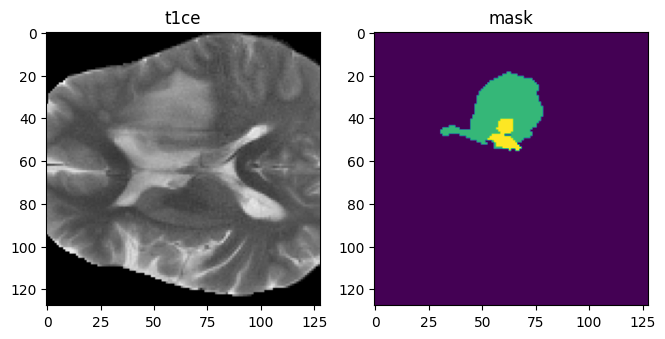

In [55]:
import random 
n_slice=random.randint(0, test_mask.shape[2])
plt.figure(figsize=(12,8))
plt.subplot(231)
plt.title("flair")
plt.imshow(combined_x[:,:,n_slice,2],cmap='gray')


plt.figure(figsize=(12,8))
plt.subplot(232)
plt.title("t1")
plt.imshow(combined_x[:,:,n_slice,0],cmap='gray')



plt.figure(figsize=(12,8))
plt.subplot(233)
plt.title("t2")
plt.imshow(combined_x[:,:,n_slice],cmap='gray')



plt.figure(figsize=(12,8))
plt.subplot(234)
plt.title("t1ce")
plt.imshow(combined_x[:,:,n_slice,1],cmap='gray')



plt.subplot(235)
plt.title("mask")
plt.imshow(test_mask[:,:,n_slice])
plt.show()

In [56]:
imsave('combined_x.tif',combined_x)
np.save('combined_x.npy', combined_x)

C:\Users\Nidhi\AppData\Local\Temp\ipykernel_28116\2034177187.py:1: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave('combined_x.tif',combined_x)


In [57]:
my_image=np.load('combined_x.npy')

In [58]:
test_mask=to_categorical(test_mask, num_classes=4)

In [67]:
t1_list=sorted(glob.glob("E:\BraTS 2020\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData\BraTS20_Training_*\BraTS20_Training_*_t1.nii"))

In [69]:
t2_list=sorted(glob.glob("E:\BraTS 2020\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData\BraTS20_Training_*\BraTS20_Training_*_t2.nii"))
t1ce_list=sorted(glob.glob("E:\BraTS 2020\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData\BraTS20_Training_*\BraTS20_Training_*_t1ce.nii"))
flair_list=sorted(glob.glob("E:\BraTS 2020\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData\BraTS20_Training_*\BraTS20_Training_*_flair.nii"))

In [70]:
mask_list=sorted(glob.glob("E:\BraTS 2020\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData\BraTS20_Training_*\BraTS20_Training_*_seg.nii"))

In [75]:
len(mask_list)

369

In [82]:
for img in range(len(t2_list)):
    print("preparing image and masks for number ", img)
    
    temp_image_t2=nib.load(t2_list[img]).get_fdata()
    temp_image_t2=scaler.fit_transform(temp_image_t2.reshape(-1, temp_image_t2.shape[-1])).reshape(temp_image_t2.shape)
    
    temp_image_flair=nib.load(flair_list[img]).get_fdata()
    temp_image_flair=scaler.fit_transform(temp_image_flair.reshape(-1, temp_image_flair.shape[-1])).reshape(temp_image_flair.shape)
    
    temp_image_t1ce=nib.load(t1ce_list[img]).get_fdata()
    temp_image_t1ce=scaler.fit_transform(temp_image_t1ce.reshape(-1, temp_image_t1ce.shape[-1])).reshape(temp_image_t1ce.shape)
    
    temp_mask=nib.load(mask_list[img]).get_fdata()
    temp_mask=temp_mask.astype(np.uint8)
    temp_mask[temp_mask==4]=3
    
    temp_combined_images=np.stack([temp_image_flair, temp_image_t1ce, temp_image_t2], axis=3)
    
    temp_combined_images=temp_combined_images[56:184, 56:184, 13:141]
    temp_mask=temp_mask[56:184, 56:184, 13:141]
    
    val, counts= np.unique(temp_mask, return_counts=True)
    
    if(1-counts[0] / counts.sum())>0.01 :
        print("save")
        
        temp_mask=to_categorical(temp_mask, num_classes=4)
        np.save("E:/BraTS 2020/BraTS2020_TrainingData/input_data_3channels/images/image_"+str(img)+".npy", temp_combined_images)
        np.save("E:/BraTS 2020/BraTS2020_TrainingData/input_data_3channels/masks/mask_"+str(img)+".npy", temp_mask)
        
    else:
        print("im useless")


preparing image and masks for number  0
save
preparing image and masks for number  1
save
preparing image and masks for number  2
save
preparing image and masks for number  3
save
preparing image and masks for number  4
im useless
preparing image and masks for number  5
save
preparing image and masks for number  6
save
preparing image and masks for number  7
save
preparing image and masks for number  8
save
preparing image and masks for number  9
save
preparing image and masks for number  10
save
preparing image and masks for number  11
save
preparing image and masks for number  12
save
preparing image and masks for number  13
save
preparing image and masks for number  14
save
preparing image and masks for number  15
save
preparing image and masks for number  16
save
preparing image and masks for number  17
save
preparing image and masks for number  18
save
preparing image and masks for number  19
save
preparing image and masks for number  20
save
preparing image and masks for number  

save
preparing image and masks for number  175
save
preparing image and masks for number  176
im useless
preparing image and masks for number  177
save
preparing image and masks for number  178
save
preparing image and masks for number  179
save
preparing image and masks for number  180
save
preparing image and masks for number  181
save
preparing image and masks for number  182
save
preparing image and masks for number  183
save
preparing image and masks for number  184
save
preparing image and masks for number  185
save
preparing image and masks for number  186
save
preparing image and masks for number  187
save
preparing image and masks for number  188
save
preparing image and masks for number  189
save
preparing image and masks for number  190
save
preparing image and masks for number  191
save
preparing image and masks for number  192
save
preparing image and masks for number  193
save
preparing image and masks for number  194
save
preparing image and masks for number  195
save
pr

preparing image and masks for number  348
save
preparing image and masks for number  349
save
preparing image and masks for number  350
save
preparing image and masks for number  351
save
preparing image and masks for number  352
save
preparing image and masks for number  353
save
preparing image and masks for number  354
save
preparing image and masks for number  355
save
preparing image and masks for number  356
save
preparing image and masks for number  357
save
preparing image and masks for number  358
save
preparing image and masks for number  359
save
preparing image and masks for number  360
save
preparing image and masks for number  361
save
preparing image and masks for number  362
save
preparing image and masks for number  363
save
preparing image and masks for number  364
save
preparing image and masks for number  365
save
preparing image and masks for number  366
save
preparing image and masks for number  367
save
preparing image and masks for number  368
save


In [84]:
#!pip install split-folders


[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [85]:
import splitfolders

input_folder='E:\BraTS 2020\BraTS2020_TrainingData\input_data_3channels'
output_folder='E:\BraTS 2020\BraTS2020_TrainingData\input_data_128'

splitfolders.ratio(input_folder, output=output_folder, seed=42, ratio=(0.75,0.25), group_prefix=None)

Copying files: 688 files [16:39,  1.45s/ files]


In [104]:
def load_img(img_dir, img_list):
    images=[]
    for i, img_name in enumerate(img_list):
        if(img_name.split('.')[1]=='npy'):
            image=np.load(img_dir+img_name)
            images.append(image)
    images=np.array(images)
    return images

In [105]:
def img_loader(img_dir, img_list, mask_dir, mask_list, batch_size):
    L=len(img_list)
    
    while True:
        batch_start=0
        batch_end=batch_size
        while batch_start<L:
            limit=min(batch_end, L)
            X=load_img(img_dir, img_list[batch_start:limit])
            Y=load_img(mask_dir, mask_list[batch_start:limit])
            
            yield(X,Y)
            
            batch_start+=batch_size
            batch_end+=batch_size
            

In [106]:
import matplotlib.pyplot as plt
import random
import os

train_img_dir="E:/BraTS 2020/BraTS2020_TrainingData/input_data_128/train/images/"
mask_img_dir="E:/BraTS 2020/BraTS2020_TrainingData/input_data_128/train/masks/"

train_img_list=os.listdir(train_img_dir)
mask_img_list=os.listdir(mask_img_dir)

batch_size=2

train_img_datagen=img_loader(train_img_dir, train_img_list, mask_img_dir, mask_img_list, batch_size)



In [123]:
img,msk=train_img_datagen.__next__()

In [124]:
img_num=random.randint(0, img.shape[0]-1)
test_img=img[img_num]
test_mask=msk[img_num]
test_mask=np.argmax(test_mask,axis=3)#converts decimal to integer, mention axis else along all it gives max which is scalar



In [125]:
test_mask

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

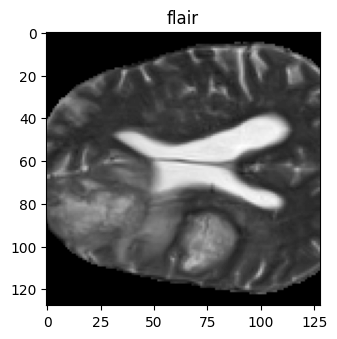

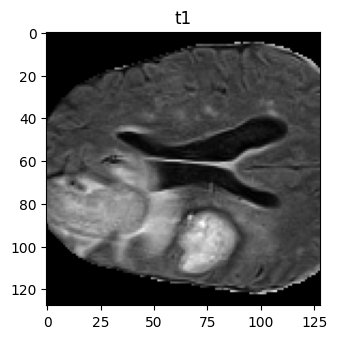

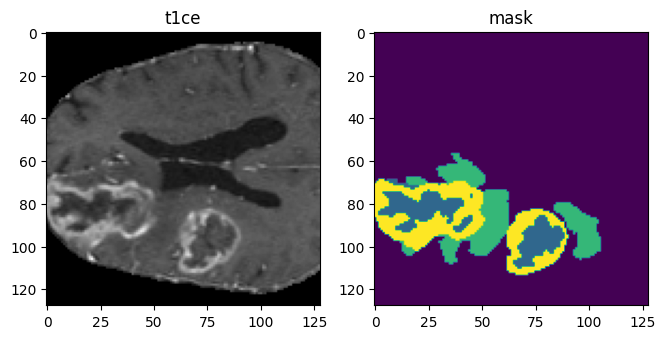

In [126]:
n_slice=random.randint(0, test_mask.shape[2])
plt.figure(figsize=(12,8))
plt.subplot(231)
plt.title("flair")
plt.imshow(test_img[:,:,n_slice,2],cmap='gray')


plt.figure(figsize=(12,8))
plt.subplot(232)
plt.title("t1")
plt.imshow(test_img[:,:,n_slice,0],cmap='gray')

plt.figure(figsize=(12,8))
plt.subplot(234)
plt.title("t1ce")
plt.imshow(test_img[:,:,n_slice,1],cmap='gray')



plt.subplot(235)
plt.title("mask")
plt.imshow(test_mask[:,:,n_slice])
plt.show()


In [127]:
from keras.models import Model
from keras.layers import Input, Conv3D, MaxPooling3D, concatenate, Conv3DTranspose, BatchNormalization, Dropout, Lambda
from keras.optimizers import Adam
from keras.metrics import MeanIoU

kernel_initializer =  'he_uniform' #Try others if you want


################################################################
def simple_unet_model(IMG_HEIGHT, IMG_WIDTH, IMG_DEPTH, IMG_CHANNELS, num_classes):
#Build the model
    inputs = Input((IMG_HEIGHT, IMG_WIDTH, IMG_DEPTH, IMG_CHANNELS))
    #s = Lambda(lambda x: x / 255)(inputs)   #No need for this if we normalize our inputs beforehand
    s = inputs

    #Contraction path
    c1 = Conv3D(16, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(s)
    c1 = Dropout(0.1)(c1)
    c1 = Conv3D(16, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c1)
    p1 = MaxPooling3D((2, 2, 2))(c1)
    
    c2 = Conv3D(32, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(p1)
    c2 = Dropout(0.1)(c2)
    c2 = Conv3D(32, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c2)
    p2 = MaxPooling3D((2, 2, 2))(c2)
     
    c3 = Conv3D(64, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(p2)
    c3 = Dropout(0.2)(c3)
    c3 = Conv3D(64, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c3)
    p3 = MaxPooling3D((2, 2, 2))(c3)
     
    c4 = Conv3D(128, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(p3)
    c4 = Dropout(0.2)(c4)
    c4 = Conv3D(128, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c4)
    p4 = MaxPooling3D(pool_size=(2, 2, 2))(c4)
     
    c5 = Conv3D(256, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(p4)
    c5 = Dropout(0.3)(c5)
    c5 = Conv3D(256, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c5)
    
    #Expansive path 
    u6 = Conv3DTranspose(128, (2, 2, 2), strides=(2, 2, 2), padding='same')(c5)
    u6 = concatenate([u6, c4])
    c6 = Conv3D(128, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(u6)
    c6 = Dropout(0.2)(c6)
    c6 = Conv3D(128, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c6)
     
    u7 = Conv3DTranspose(64, (2, 2, 2), strides=(2, 2, 2), padding='same')(c6)
    u7 = concatenate([u7, c3])
    c7 = Conv3D(64, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(u7)
    c7 = Dropout(0.2)(c7)
    c7 = Conv3D(64, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c7)
     
    u8 = Conv3DTranspose(32, (2, 2, 2), strides=(2, 2, 2), padding='same')(c7)
    u8 = concatenate([u8, c2])
    c8 = Conv3D(32, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(u8)
    c8 = Dropout(0.1)(c8)
    c8 = Conv3D(32, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c8)
     
    u9 = Conv3DTranspose(16, (2, 2, 2), strides=(2, 2, 2), padding='same')(c8)
    u9 = concatenate([u9, c1])
    c9 = Conv3D(16, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(u9)
    c9 = Dropout(0.1)(c9)
    c9 = Conv3D(16, (3, 3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(c9)
     
    outputs = Conv3D(num_classes, (1, 1, 1), activation='softmax')(c9)
     
    model = Model(inputs=[inputs], outputs=[outputs])
    #compile model outside of this function to make it flexible. 
    model.summary()
    
    return model

#Test if everything is working ok. 
model = simple_unet_model(128, 128, 128, 3, 4)
print(model.input_shape)
print(model.output_shape)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 128, 128, 128, 3)  │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv3d (Conv3D)               │ (None, 128, 128, 128, 16) │           1,312 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 128, 128, 128, 16) │               0 │ conv3d[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv3d_1 (Conv3D)             │ (None, 128, 128, 128, 16) │           6,928 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling3d (MaxPooling3D)  │ (None, 64, 64, 64, 16)    │               0 │ conv3d_1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv3d_2 (Conv3D)             │ (None, 64, 64, 64, 32)    │          13,856 │ max_pooling3d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 64, 64, 64, 32)    │               0 │ conv3d_2[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv3d_3 (Conv3D)             │ (None, 64, 64, 64, 32)    │          27,680 │ dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling3d_1               │ (None, 32, 32, 32, 32)    │               0 │ conv3d_3[0][0]             │
│ (MaxPooling3D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv3d_4 (Conv3D)             │ (None, 32, 32, 32, 64)    │          55,360 │ max_pooling3d_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_2 (Dropout)           │ (None, 32, 32, 32, 64)    │               0 │ conv3d_4[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv3d_5 (Conv3D)             │ (None, 32, 32, 32, 64)    │         110,656 │ dropout_2[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling3d_2               │ (None, 16, 16, 16, 64)    │               0 │ conv3d_5[0][0]             │
│ (MaxPooling3D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv3d_6 (Conv3D)             │ (None, 16, 16, 16, 128)   │         221,312 │ max_pooling3d_2[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_3 (Dropout)           │ (None, 16, 16, 16, 128)   │               0 │ conv3d_6[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv3d_7 (Conv3D)             │ (None, 16, 16, 16, 128)   │         442,496 │ dropout_3[0][0]            │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 5,645,828 (21.54 MB)

 Trainable params: 5,645,828 (21.54 MB)

 Non-trainable params: 0 (0.00 B)

(None, 128, 128, 128, 3)
(None, 128, 128, 128, 4)


In [129]:
model=simple_unet_model(128,128,128,3,4)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 128, 128, 128, 3)  │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv3d_19 (Conv3D)            │ (None, 128, 128, 128, 16) │           1,312 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_9 (Dropout)           │ (None, 128, 128, 128, 16) │               0 │ conv3d_19[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv3d_20 (Conv3D)            │ (None, 128, 128, 128, 16) │           6,928 │ dropout_9[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling3d_4               │ (None, 64, 64, 64, 16)    │               0 │ conv3d_20[0][0]            │
│ (MaxPooling3D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv3d_21 (Conv3D)            │ (None, 64, 64, 64, 32)    │          13,856 │ max_pooling3d_4[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_10 (Dropout)          │ (None, 64, 64, 64, 32)    │               0 │ conv3d_21[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv3d_22 (Conv3D)            │ (None, 64, 64, 64, 32)    │          27,680 │ dropout_10[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling3d_5               │ (None, 32, 32, 32, 32)    │               0 │ conv3d_22[0][0]            │
│ (MaxPooling3D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv3d_23 (Conv3D)            │ (None, 32, 32, 32, 64)    │          55,360 │ max_pooling3d_5[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_11 (Dropout)          │ (None, 32, 32, 32, 64)    │               0 │ conv3d_23[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv3d_24 (Conv3D)            │ (None, 32, 32, 32, 64)    │         110,656 │ dropout_11[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling3d_6               │ (None, 16, 16, 16, 64)    │               0 │ conv3d_24[0][0]            │
│ (MaxPooling3D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv3d_25 (Conv3D)            │ (None, 16, 16, 16, 128)   │         221,312 │ max_pooling3d_6[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_12 (Dropout)          │ (None, 16, 16, 16, 128)   │               0 │ conv3d_25[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv3d_26 (Conv3D)            │ (None, 16, 16, 16, 128)   │         442,49

 Total params: 5,645,828 (21.54 MB)

 Trainable params: 5,645,828 (21.54 MB)

 Non-trainable params: 0 (0.00 B)

In [130]:
print(model.input_shape)

(None, 128, 128, 128, 3)


In [132]:
print(model.output_shape)

(None, 128, 128, 128, 4)


In [133]:
#put distribution code if you want video 234 12.11

In [138]:
wt0,wt1,wt2,wt3=0.25,0.25,0.25,0.25
import segmentation_models_3D as sm
dice_loss=sm.losses.DiceLoss(class_weights=np.array([wt0,wt1,wt2,wt3]))
focal_loss=sm.losses.CategoricalFocalLoss()
total_loss=dice_loss+(1*focal_loss)



In [141]:
#!pip install segmentation_models_3D
import keras

In [161]:
def safe_iou_score(gt, pr):
    gt = tf.cast(gt, tf.float32)
    pr = tf.cast(pr, tf.float32)
    return sm.metrics.IOUScore(threshold=0.5)(gt, pr)

metrics = ['accuracy', safe_iou_score]


In [162]:

LR=0.0001
optim=keras.optimizers.Adam(LR)
steps_per_epoch=len(train_img_list)//batch_size
val_steps_per_epoch=len(mask_img_list)//batch_size



model=simple_unet_model(IMG_HEIGHT=128, IMG_WIDTH=128, IMG_DEPTH=128, IMG_CHANNELS=3, num_classes=4)
model.compile(optimizer=optim, loss=total_loss, metrics=metrics)

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)    │ (None, 128, 128, 128, 3)  │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv3d_114 (Conv3D)           │ (None, 128, 128, 128, 16) │           1,312 │ input_layer_6[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_54 (Dropout)          │ (None, 128, 128, 128, 16) │               0 │ conv3d_114[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv3d_115 (Conv3D)           │ (None, 128, 128, 128, 16) │           6,928 │ dropout_54[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling3d_24              │ (None, 64, 64, 64, 16)    │               0 │ conv3d_115[0][0]           │
│ (MaxPooling3D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv3d_116 (Conv3D)           │ (None, 64, 64, 64, 32)    │          13,856 │ max_pooling3d_24[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_55 (Dropout)          │ (None, 64, 64, 64, 32)    │               0 │ conv3d_116[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv3d_117 (Conv3D)           │ (None, 64, 64, 64, 32)    │          27,680 │ dropout_55[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling3d_25              │ (None, 32, 32, 32, 32)    │               0 │ conv3d_117[0][0]           │
│ (MaxPooling3D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv3d_118 (Conv3D)           │ (None, 32, 32, 32, 64)    │          55,360 │ max_pooling3d_25[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_56 (Dropout)          │ (None, 32, 32, 32, 64)    │               0 │ conv3d_118[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv3d_119 (Conv3D)           │ (None, 32, 32, 32, 64)    │         110,656 │ dropout_56[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling3d_26              │ (None, 16, 16, 16, 64)    │               0 │ conv3d_119[0][0]           │
│ (MaxPooling3D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv3d_120 (Conv3D)           │ (None, 16, 16, 16, 128)   │         221,312 │ max_pooling3d_26[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_57 (Dropout)          │ (None, 16, 16, 16, 128)   │               0 │ conv3d_120[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv3d_121 (Conv3D)           │ (None, 16, 16, 16, 128)   │         442,49

 Total params: 5,645,828 (21.54 MB)

 Trainable params: 5,645,828 (21.54 MB)

 Non-trainable params: 0 (0.00 B)

In [157]:
val_img_dir ="E:/BraTS 2020/BraTS2020_TrainingData/input_data_128/val/images/"
val_mask_dir = "E:/BraTS 2020/BraTS2020_TrainingData/input_data_128/val/masks/"



val_img_list=os.listdir(val_img_dir)
val_mask_list = os.listdir(val_mask_dir)



val_img_datagen = img_loader(val_img_dir, val_img_list, 
                                val_mask_dir, val_mask_list, batch_size)


In [163]:
history=model.fit(train_img_datagen,steps_per_epoch=steps_per_epoch , epochs=10, validation_data=val_img_datagen, validation_steps=val_steps_per_epoch)

Epoch 1/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 1790s 14s/step - accuracy: 0.7615 - loss: 0.9742 - safe_iou_score: 0.1463 - val_accuracy: 0.9200 - val_loss: 0.9642 - val_safe_iou_score: 0.1392
Epoch 2/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 1611s 12s/step - accuracy: 0.9395 - loss: 0.9329 - safe_iou_score: 0.2396 - val_accuracy: 0.7954 - val_loss: 0.9515 - val_safe_iou_score: 0.2568
Epoch 3/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 1670s 13s/step - accuracy: 0.9402 - loss: 0.9184 - safe_iou_score: 0.3067 - val_accuracy: 0.8636 - val_loss: 0.9356 - val_safe_iou_score: 0.3157
Epoch 4/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 1636s 13s/step - accuracy: 0.9464 - loss: 0.9099 - safe_iou_score: 0.3502 - val_accuracy: 0.8527 - val_loss: 0.9343 - val_safe_iou_score: 0.2995
Epoch 5/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 1779s 14s/step - accuracy: 0.9471 - loss: 0.9032 - safe_iou_score: 0.3577 - val_accuracy: 0.8367 - val_loss: 0.9321 - val_safe_iou_score: 0.3024
Epoch 6/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 1743s 14s/step - accuracy: 0.9482 -

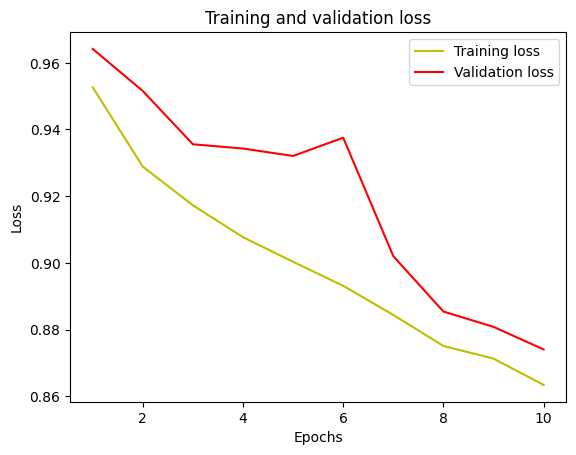

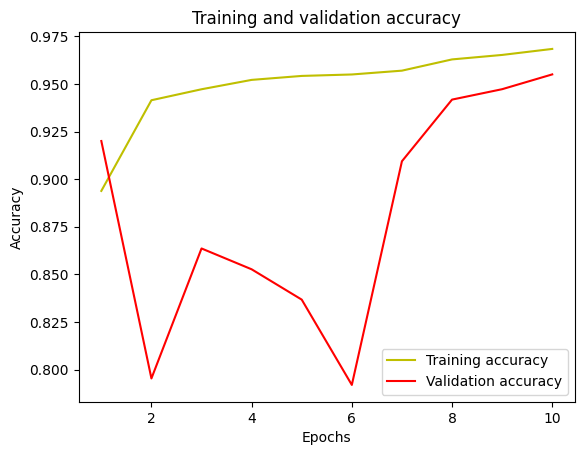

In [164]:
#plot the training and validation IoU and loss at each epoch
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.plot(epochs, acc, 'y', label='Training accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
